In [1]:
!unzip archive\ \(9\).zip

Archive:  archive (9).zip
  inflating: zomato.csv              


In [2]:
# Assuming your file is named 'zomato.csv' in the Colab sidebar
import pandas as pd

try:
    df = pd.read_csv('zomato.csv', encoding='latin-1')
    print("Dataset loaded successfully!")
    print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
    display(df.head())
except FileNotFoundError:
    print("Error: Please make sure the file is named 'zomato.csv' or change the name in the code above.")

Dataset loaded successfully!
Total Rows: 56252 | Total Columns: 13


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [4]:
# 1. Standardize all column names (removes hidden spaces and makes them lowercase)
df.columns = df.columns.str.strip().str.lower()

# 2. Find the cuisine column automatically (it might be 'cuisine' or 'cuisines')
if 'cuisines' in df.columns:
    target_cuisine_col = 'cuisines'
elif 'cuisine' in df.columns:
    df.rename(columns={'cuisine': 'cuisines'}, inplace=True)
    target_cuisine_col = 'cuisines'
else:
    # If it's something else, this finds any column containing 'cuis'
    possible_cols = [col for col in df.columns if 'cuis' in col]
    if possible_cols:
        df.rename(columns={possible_cols[0]: 'cuisines'}, inplace=True)
        target_cuisine_col = 'cuisines'
    else:
        target_cuisine_col = None

# 3. Handle missing values and basic cleaning using lowercase names
if target_cuisine_col:
    df['cuisines'] = df['cuisines'].fillna('Other')

# Drop unnecessary columns if they exist (using lowercase)
cols_to_drop = ['restaurant id', 'address', 'locality verbose']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Success! Data is now clean and column names are standardized.")
print("Current columns:", df.columns.tolist())
df.head()

Success! Data is now clean and column names are standardized.
Current columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']


,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [7]:
import plotly.express as px

# 1. Find the city column automatically
if 'city' in df.columns:
    city_col = 'city'
else:
    possible_city_cols = [col for col in df.columns if 'city' in col.lower()]
    city_col = possible_city_cols[0] if possible_city_cols else df.columns[1]

# 2. Count restaurants and create the chart
city_counts = df[city_col].value_counts().reset_index()
city_counts.columns = ['City', 'Restaurant Count']

# 3. Create the interactive bar chart
fig = px.bar(city_counts.head(10),
             x='City',
             y='Restaurant Count',
             title='Top 10 Cities with Most Restaurants (Location Hotspots)',
             color='Restaurant Count',
             color_continuous_scale='Reds',
             template='plotly_dark') # Dark theme looks very professional!

fig.show()

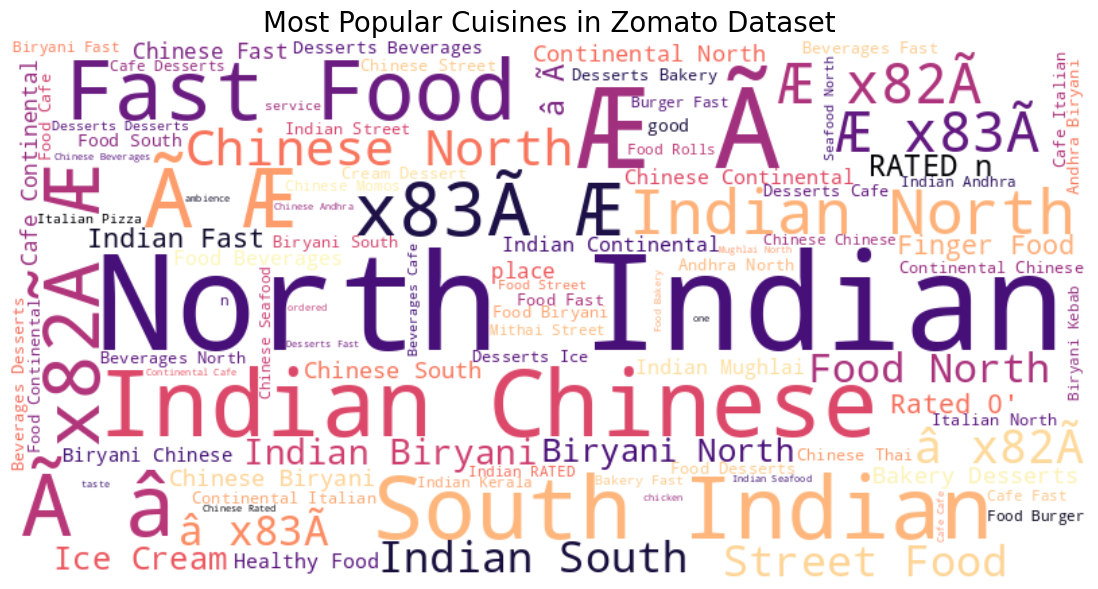

In [8]:
# 1. Install wordcloud if needed
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 2. Prepare the text data
# We take the 'cuisines' column, join all rows into one giant string
text = " ".join(cat for cat in df['cuisines'].astype(str))

# 3. Generate the WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='magma',
                      max_words=100).generate(text)

# 4. Display it
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Popular Cuisines in Zomato Dataset", fontsize=20)
plt.show()

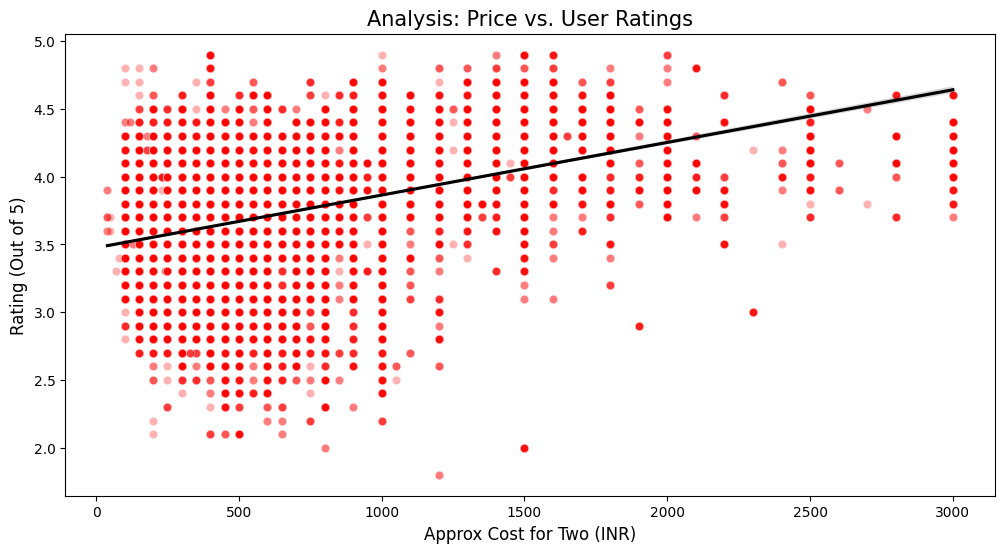

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MANUALLY SET THE CORRECT COLUMNS (Based on your error message)
cost_col = 'approx_cost(for two people)'
# We need to find the actual rating column, likely 'rate' or 'aggregate rating'
rating_col = 'rate' if 'rate' in df.columns else 'aggregate rating'

# 2. CLEANING THE DATA TYPES (Crucial Fix)
# Convert Cost to string, remove commas, and make it a float
df[cost_col] = df[cost_col].astype(str).str.replace(',', '').str.replace('None', '0')
df[cost_col] = pd.to_numeric(df[cost_col], errors='coerce')

# Convert Rating to string, remove "/5", and make it a float
if rating_col in df.columns:
    df[rating_col] = df[rating_col].astype(str).str.split('/').str[0]
    df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')

# 3. FILTER & PLOT
# Remove rows with missing or zero values so the chart is accurate
final_plot_df = df[(df[cost_col] > 0) & (df[rating_col] > 0)].copy()

# Limit cost to under 3000 to see the main data clearly
final_plot_df = final_plot_df[final_plot_df[cost_col] <= 3000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=final_plot_df, x=cost_col, y=rating_col, alpha=0.3, color='red')
sns.regplot(data=final_plot_df, x=cost_col, y=rating_col, scatter=False, color='black')

plt.title('Analysis: Price vs. User Ratings', fontsize=15)
plt.xlabel('Approx Cost for Two (INR)', fontsize=12)
plt.ylabel('Rating (Out of 5)', fontsize=12)
plt.show()